# Automatic Speech Recognition (ASR) - Training

Dataset: Suara Bunga (10 Kelas, Suara Perempuan)
Pipeline:
1. Preprocessing (Normalisasi, Bandpass, Notch)
2. Augmentasi Data
3. Ekstraksi Fitur (MFCC + Delta + Delta-Delta)
4. Training (MLP, CNN-1D, SVM)
5. Evaluasi & Perbandingan


In [7]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from scipy.signal import butter, lfilter, iirnotch
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, GlobalAveragePooling1D, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings

warnings.filterwarnings('ignore')

# Cek GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"[INFO] {len(gpus)} GPU terdeteksi.")
    except RuntimeError as e:
        print(e)
else:
    print("[WARNING] Menggunakan CPU.")


[INFO] 1 GPU terdeteksi.


## 1. Konfigurasi Parameter


In [8]:
DATASET_PATH = 'dataset'
MODEL_SAVE_PATH = 'models'

# Buat folder models jika belum ada
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# Parameter Audio
SAMPLE_RATE = 16000
DURATION = 2.0  # Semua audio disamakan menjadi 2 detik
N_MFCC = 40

# Daftar Kelas
CLASSES = sorted(['alamanda', 'anggrek', 'dahlia', 'krisan', 'lily', 
                  'matahari', 'mawar', 'melati', 'teratai', 'tulip'])

print(f"Total kelas: {len(CLASSES)}")
print(f"Sample Rate: {SAMPLE_RATE} Hz")
print(f"Durasi Maksimal: {DURATION} detik")


Total kelas: 10
Sample Rate: 16000 Hz
Durasi Maksimal: 2.0 detik


## 2. Fungsi Preprocessing Audio
* Bandpass Filter (300 - 3400 Hz) untuk fokus pada frekuensi suara manusia
* Notch Filter (50 Hz) untuk menghilangkan dengung listrik


In [9]:
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(data, fs, lowcut=300.0, highcut=3400.0, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = lfilter(b, a, data)
    return y

def apply_notch_filter(data, fs, freq=50.0, q=30.0):
    nyq = 0.5 * fs
    w0 = freq / nyq
    b, a = iirnotch(w0, q)
    y = lfilter(b, a, data)
    return y

def preprocess_audio(file_path):
    # 1. Load dan Resample
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    
    # 2. Normalisasi Amplitudo
    y = librosa.util.normalize(y)
    
    # 3. Filtering
    y = apply_bandpass_filter(y, sr)
    y = apply_notch_filter(y, sr)
    
    # 4. Padding / Trimming
    max_len = int(SAMPLE_RATE * DURATION)
    if len(y) > max_len:
        y = y[:max_len]
    else:
        pad_width = max_len - len(y)
        y = np.pad(y, (0, pad_width), mode='constant')
        
    return y, sr


## 3. Augmentasi Data dan Ekstraksi MFCC


In [10]:
# Fungsi Augmentasi
def add_noise(data, noise_factor=0.005):
    noise = np.random.randn(len(data))
    return data + noise_factor * noise

def time_shift(data, shift_max=0.2, sr=SAMPLE_RATE):
    shift = np.random.randint(int(sr * shift_max))
    if np.random.rand() > 0.5:
        shift = -shift
    augmented_data = np.roll(data, shift)
    if shift > 0:
        augmented_data[:shift] = 0
    else:
        augmented_data[shift:] = 0
    return augmented_data

# Fungsi Ekstraksi MFCC
def extract_mfcc(y, sr=SAMPLE_RATE, n_mfcc=N_MFCC, return_sequence=False):
    # Ekstrak MFCC dasar
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    
    # Delta dan Delta-Delta
    delta_mfcc = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)
    
    # Gabung menjadi (120, TimeFrames)
    combined = np.concatenate((mfcc, delta_mfcc, delta2_mfcc))
    
    if return_sequence:
        # Transpose untuk CNN-1D: (TimeFrames, 120)
        return combined.T
    else:
        # Mean dan Std untuk MLP & SVM: (240,)
        mfcc_mean = np.mean(combined, axis=1)
        mfcc_std = np.std(combined, axis=1)
        return np.concatenate((mfcc_mean, mfcc_std))


## 4. Memuat Dataset (Asli + Augmentasi)


In [11]:
def load_and_extract_features():
    X_seq, X_flat, y_labels = [], [], []
    
    for label in CLASSES:
        folder_path = os.path.join(DATASET_PATH, label)
        if not os.path.exists(folder_path):
            continue
            
        files = glob.glob(os.path.join(folder_path, '*.wav'))
        print(f"Memproses {len(files)} file kelas: {label}")
        
        for file in files:
            # Data Asli (Murni)
            y_audio, sr = preprocess_audio(file)
            X_seq.append(extract_mfcc(y_audio, return_sequence=True))
            X_flat.append(extract_mfcc(y_audio, return_sequence=False))
            y_labels.append(label)
            
            # Augmentasi 1: Noise
            y_noise = add_noise(y_audio)
            X_seq.append(extract_mfcc(y_noise, return_sequence=True))
            X_flat.append(extract_mfcc(y_noise, return_sequence=False))
            y_labels.append(label)
            
            # Augmentasi 2: Time Shift
            y_shift = time_shift(y_audio)
            X_seq.append(extract_mfcc(y_shift, return_sequence=True))
            X_flat.append(extract_mfcc(y_shift, return_sequence=False))
            y_labels.append(label)

    return np.array(X_seq), np.array(X_flat), np.array(y_labels)

X_seq, X_flat, y_labels = load_and_extract_features()
print(f"\nTotal data (setelah augmentasi): {len(y_labels)}")
print(f"Shape CNN (X_seq): {X_seq.shape}")
print(f"Shape MLP/SVM (X_flat): {X_flat.shape}")


Memproses 20 file kelas: alamanda
Memproses 20 file kelas: anggrek
Memproses 20 file kelas: dahlia
Memproses 20 file kelas: krisan
Memproses 20 file kelas: lily
Memproses 20 file kelas: matahari
Memproses 20 file kelas: mawar
Memproses 20 file kelas: melati
Memproses 20 file kelas: teratai
Memproses 20 file kelas: tulip

Total data (setelah augmentasi): 600
Shape CNN (X_seq): (600, 63, 120)
Shape MLP/SVM (X_flat): (600, 240)


## 5. Splitting Data dan Scaling


In [12]:
# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
y_cat = tf.keras.utils.to_categorical(y_encoded, num_classes=len(CLASSES))

joblib.dump(le, os.path.join(MODEL_SAVE_PATH, 'label_encoder.pkl'))

# Split Flat (MLP, SVM)
X_train_flat, X_test_flat, y_train, y_test, y_train_cat, y_test_cat = train_test_split(
    X_flat, y_encoded, y_cat, test_size=0.2, random_state=42, stratify=y_encoded
)

# Split Sequential (CNN-1D)
X_train_seq, X_test_seq, _, _ = train_test_split(
    X_seq, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Standard Scaler (Hanya untuk fitur flat)
scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)

joblib.dump(scaler, os.path.join(MODEL_SAVE_PATH, 'scaler.pkl'))

print(f"Training data: {X_train_flat.shape[0]}")
print(f"Testing data: {X_test_flat.shape[0]}")


Training data: 480
Testing data: 120


## 6. Training & Evaluasi MLP


In [13]:
def build_mlp(input_shape):
    model = Sequential([
        Input(shape=(input_shape,)),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(len(CLASSES), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

mlp = build_mlp(X_train_flat.shape[1])
callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True),
    ModelCheckpoint(os.path.join(MODEL_SAVE_PATH, 'model_mlp.h5'), save_best_only=True),
    ReduceLROnPlateau(factor=0.5, patience=5)
]

print("Training MLP...")
hist_mlp = mlp.fit(X_train_flat, y_train_cat, validation_data=(X_test_flat, y_test_cat),
                   epochs=100, batch_size=32, callbacks=callbacks, verbose=1)


Training MLP...
Epoch 1/100
15/15 [==============================] - 6s 56ms/step - loss: 2.6181 - accuracy: 0.1896 - val_loss: 1.9334 - val_accuracy: 0.3333 - lr: 0.0010
Epoch 2/100
15/15 [==============================] - 0s 21ms/step - loss: 1.3256 - accuracy: 0.5354 - val_loss: 1.5613 - val_accuracy: 0.5750 - lr: 0.0010
Epoch 3/100
15/15 [==============================] - 0s 19ms/step - loss: 0.8803 - accuracy: 0.7083 - val_loss: 1.2561 - val_accuracy: 0.7000 - lr: 0.0010
Epoch 4/100
15/15 [==============================] - 0s 20ms/step - loss: 0.5523 - accuracy: 0.8375 - val_loss: 1.0169 - val_accuracy: 0.7833 - lr: 0.0010
Epoch 5/100
15/15 [==============================] - 0s 18ms/step - loss: 0.3620 - accuracy: 0.9229 - val_loss: 0.7953 - val_accuracy: 0.8833 - lr: 0.0010
Epoch 6/100
15/15 [==============================] - 0s 18ms/step - loss: 0.2686 - accuracy: 0.9396 - val_loss: 0.6488 - val_accuracy: 0.8917 - lr: 0.0010
Epoch 7/100
15/15 [==============================] - 0

Evaluasi MLP:
4/4 [==============================] - 0s 5ms/step
              precision    recall  f1-score   support

    alamanda       0.92      1.00      0.96        12
     anggrek       0.92      1.00      0.96        12
      dahlia       1.00      0.92      0.96        12
      krisan       0.92      1.00      0.96        12
        lily       1.00      1.00      1.00        12
    matahari       1.00      1.00      1.00        12
       mawar       0.92      0.92      0.92        12
      melati       1.00      0.83      0.91        12
     teratai       1.00      1.00      1.00        12
       tulip       1.00      1.00      1.00        12

    accuracy                           0.97       120
   macro avg       0.97      0.97      0.97       120
weighted avg       0.97      0.97      0.97       120



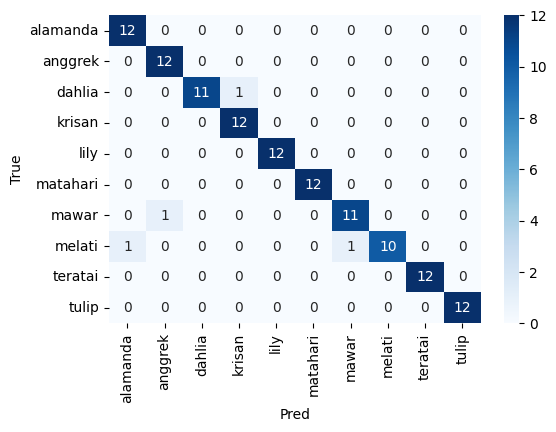

In [14]:
def evaluate_model(model, X_test, y_test_true, is_nn=True):
    if is_nn:
        y_pred = np.argmax(model.predict(X_test), axis=1)
    else:
        y_pred = model.predict(X_test)
        
    print(classification_report(y_test_true, y_pred, target_names=CLASSES))
    
    cm = confusion_matrix(y_test_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.ylabel('True')
    plt.xlabel('Pred')
    plt.show()
    return accuracy_score(y_test_true, y_pred)

print("Evaluasi MLP:")
acc_mlp = evaluate_model(mlp, X_test_flat, y_test)


## 7. Training & Evaluasi CNN-1D


In [15]:
def build_cnn1d(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(128, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        Conv1D(256, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        Conv1D(512, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        GlobalAveragePooling1D(),
        
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(len(CLASSES), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn1d = build_cnn1d(X_train_seq.shape[1:])
callbacks_cnn = [
    EarlyStopping(patience=15, restore_best_weights=True),
    ModelCheckpoint(os.path.join(MODEL_SAVE_PATH, 'model_cnn1d.h5'), save_best_only=True),
    ReduceLROnPlateau(factor=0.5, patience=5)
]

print("Training CNN-1D...")
hist_cnn = cnn1d.fit(X_train_seq, y_train_cat, validation_data=(X_test_seq, y_test_cat),
                     epochs=100, batch_size=32, callbacks=callbacks_cnn, verbose=1)


Training CNN-1D...
Epoch 1/100
15/15 [==============================] - 44s 49ms/step - loss: 1.7091 - accuracy: 0.4167 - val_loss: 5.4455 - val_accuracy: 0.1917 - lr: 0.0010
Epoch 2/100
15/15 [==============================] - 0s 23ms/step - loss: 0.4693 - accuracy: 0.8958 - val_loss: 5.0019 - val_accuracy: 0.2417 - lr: 0.0010
Epoch 3/100
15/15 [==============================] - 0s 26ms/step - loss: 0.0985 - accuracy: 0.9875 - val_loss: 2.4146 - val_accuracy: 0.5167 - lr: 0.0010
Epoch 4/100
15/15 [==============================] - 0s 22ms/step - loss: 0.0342 - accuracy: 0.9937 - val_loss: 1.7724 - val_accuracy: 0.4667 - lr: 0.0010
Epoch 5/100
15/15 [==============================] - 0s 22ms/step - loss: 0.0267 - accuracy: 0.9937 - val_loss: 1.0810 - val_accuracy: 0.7083 - lr: 0.0010
Epoch 6/100
15/15 [==============================] - 0s 24ms/step - loss: 0.0120 - accuracy: 1.0000 - val_loss: 0.2673 - val_accuracy: 0.9000 - lr: 0.0010
Epoch 7/100
15/15 [==============================]

Evaluasi CNN-1D:
4/4 [==============================] - 0s 6ms/step
              precision    recall  f1-score   support

    alamanda       1.00      1.00      1.00        12
     anggrek       1.00      1.00      1.00        12
      dahlia       1.00      1.00      1.00        12
      krisan       1.00      1.00      1.00        12
        lily       1.00      1.00      1.00        12
    matahari       1.00      1.00      1.00        12
       mawar       1.00      1.00      1.00        12
      melati       1.00      1.00      1.00        12
     teratai       1.00      1.00      1.00        12
       tulip       1.00      1.00      1.00        12

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



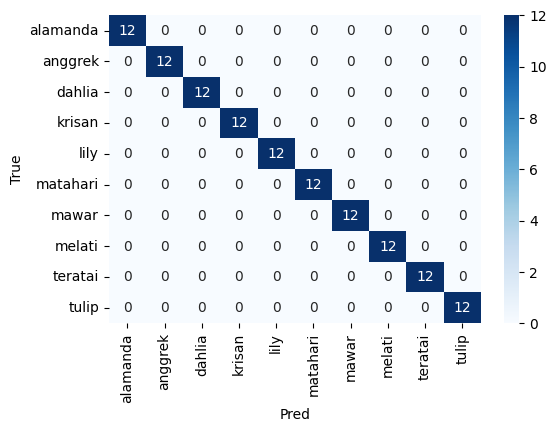

In [16]:
print("Evaluasi CNN-1D:")
acc_cnn = evaluate_model(cnn1d, X_test_seq, y_test)


## 8. Training & Evaluasi SVM


Training SVM...
Evaluasi SVM:
              precision    recall  f1-score   support

    alamanda       0.92      1.00      0.96        12
     anggrek       1.00      1.00      1.00        12
      dahlia       1.00      1.00      1.00        12
      krisan       1.00      1.00      1.00        12
        lily       1.00      1.00      1.00        12
    matahari       1.00      1.00      1.00        12
       mawar       0.85      0.92      0.88        12
      melati       1.00      0.83      0.91        12
     teratai       1.00      1.00      1.00        12
       tulip       1.00      1.00      1.00        12

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120



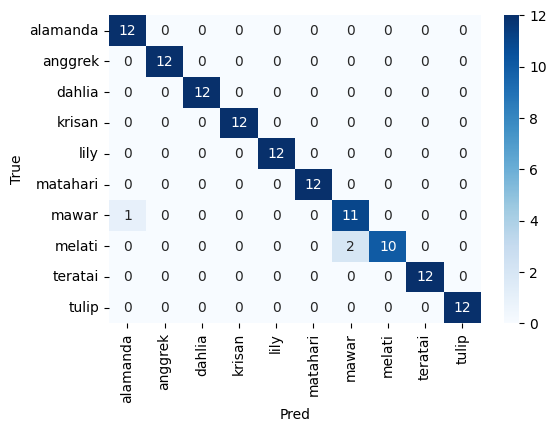

In [17]:
print("Training SVM...")
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
svm.fit(X_train_flat, y_train)

joblib.dump(svm, os.path.join(MODEL_SAVE_PATH, 'model_svm.pkl'))

print("Evaluasi SVM:")
acc_svm = evaluate_model(svm, X_test_flat, y_test, is_nn=False)


## 9. Kesimpulan


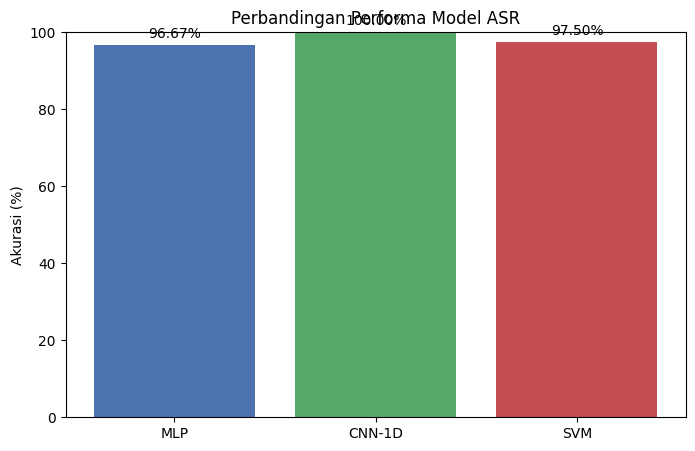

In [18]:
models = ['MLP', 'CNN-1D', 'SVM']
accuracies = [acc_mlp * 100, acc_cnn * 100, acc_svm * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylim(0, 100)
plt.ylabel('Akurasi (%)')
plt.title('Perbandingan Performa Model ASR')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', va='bottom')

plt.show()
